<a href="https://colab.research.google.com/github/YYM89/MSSP607/blob/main/Par8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
import pandas as pd
import numpy as np
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

In [3]:
df = pd.read_csv("/content/drive/MyDrive/MSSP607/Data/InternetSales.csv", encoding='latin-1')

/tmp/ipython-input-1788988596.py:1: DtypeWarning: Columns (11,14,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/MSSP607/Data/InternetSales.csv", encoding='latin-1')


In [21]:
print(df.columns.tolist())

['ID', 'CustomerKey', 'GeographyKey', 'City', 'CountryRegionCode', 'EnglishCountryRegionName', 'CustomerAlternateKey', 'Title', 'FirstName', 'MiddleName', 'LastName', 'NameStyle', 'BirthDate', 'MaritalStatus', 'Suffix', 'Gender', 'EmailAddress', 'YearlyIncome', 'TotalChildren', 'NumberChildrenAtHome', 'EnglishEducation', 'SpanishEducation', 'FrenchEducation', 'EnglishOccupation', 'SpanishOccupation', 'FrenchOccupation', 'HouseOwnerFlag', 'NumberCarsOwned', 'AddressLine1', 'AddressLine2', 'Phone', 'DateFirstPurchase', 'CommuteDistance', 'ProductKey', 'EnglishProductName', 'OrderDateKey', 'DueDateKey', 'ShipDateKey', 'CustomerKey.1', 'PromotionKey', 'CurrencyKey', 'SalesTerritoryKey', 'SalesOrderNumber', 'SalesOrderLineNumber', 'RevisionNumber', 'OrderQuantity', 'UnitPrice', 'ExtendedAmount', 'UnitPriceDiscountPct', 'DiscountAmount', 'ProductStandardCost', 'TotalProductCost', 'SalesAmount', 'TaxAmt', 'Freight', 'CarrierTrackingNumber', 'CustomerPONumber', 'OrderDate', 'DueDate', 'ShipDat

In [25]:
date_col = 'OrderDate'
sales_col = 'SalesAmount'
df[date_col] = pd.to_datetime(df[date_col])
df[sales_col] = pd.to_numeric(df[sales_col], errors='coerce')
df.dropna(subset=[sales_col], inplace=True)

In [27]:
monthly_sales = df.groupby(df[date_col].dt.to_period('M'))[sales_col].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_sales = monthly_sales.sort_index()

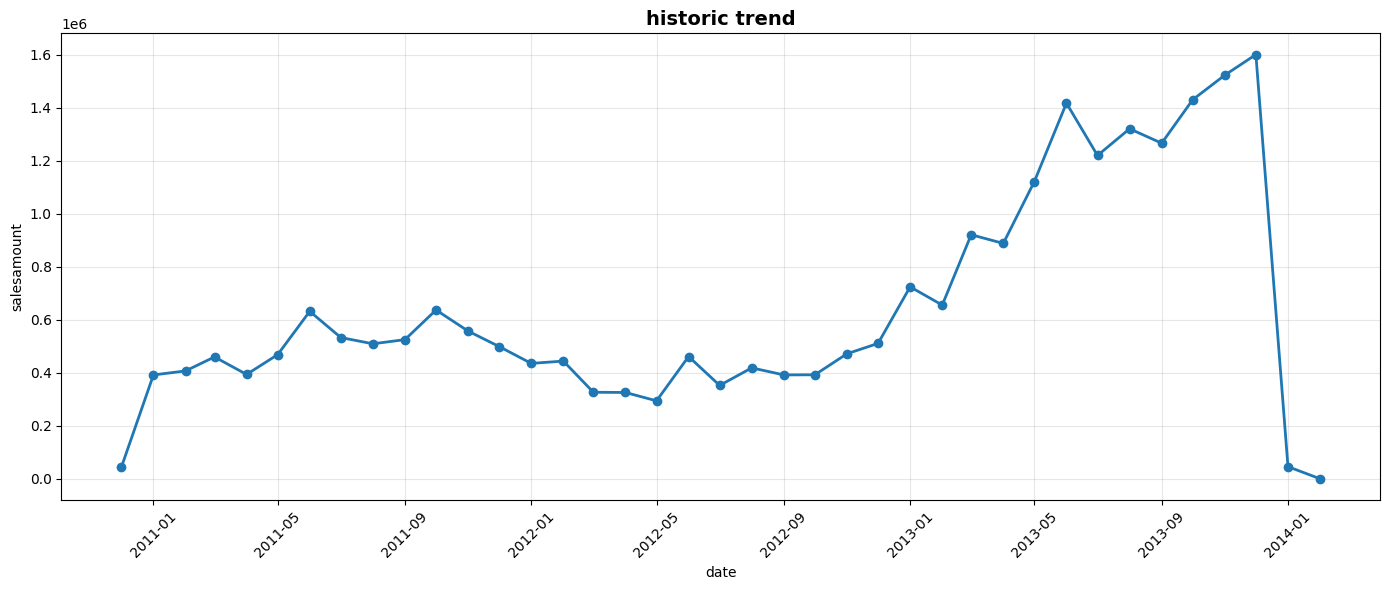

In [28]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2)
plt.title('historic trend', fontsize=14, fontweight='bold')
plt.xlabel('date')
plt.ylabel('salesamount')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
def forecast_monthly(data, months_ahead=60):
    """monthly forcast"""
    X = np.arange(len(data)).reshape(-1, 1)
    y = data.values

    model = LinearRegression()
    model.fit(X, y)

    future_X = np.arange(len(data), len(data) + months_ahead).reshape(-1, 1)
    future_pred = model.predict(future_X)

    future_dates = pd.date_range(start=data.index[-1] + pd.DateOffset(months=1),
                                  periods=months_ahead, freq='ME')
    forecast = pd.Series(future_pred, index=future_dates)

    r2 = r2_score(y, model.predict(X))

    return forecast, model, r2

monthly_forecast, monthly_model, monthly_r2 = forecast_monthly(monthly_sales)


In [18]:
monthly_forecast_df = pd.DataFrame({
    'date': monthly_forecast.index,
    'sales': monthly_forecast.values
})
monthly_forecast_df['year'] = monthly_forecast_df['date'].dt.year
monthly_to_yearly = monthly_forecast_df.groupby('year')['sales'].sum()

print("\n" + "="*60)
print("Mobthly predict:")
print("="*60)
print(f"data points：{len(monthly_sales)} ")
print(f"R² ：{monthly_r2:.4f}")
print(f"monthly increase：{monthly_model.coef_[0]:,.2f} $/m")
print("\n5 years predict（yearly）:")
print(monthly_to_yearly)


Mobthly predict:
data points：39 
R² ：0.3004
monthly increase：20,116.47 $/m

5 years predict（yearly）:
year
2014    1.134334e+07
2015    1.626738e+07
2016    1.916415e+07
2017    2.206092e+07
2018    2.495769e+07
2019    4.441246e+06
Name: sales, dtype: float64


In [43]:
#Most sales
product_col = 'EnglishProductName'
sales_col = 'SalesAmount'
price_col = 'UnitPrice'
df[product_col] = df[product_col].str.strip()
df[sales_col] = pd.to_numeric(df[sales_col], errors="coerce")

In [44]:
def price_to_category(p):
    if pd.isna(p):
        return "Unknown"
    if p > 500:
        return "Bicycles"
    if 100 < p <= 500:
        return "Bike Racks"
    if 0 <= p <= 100:
        return "Bike Accessories/Clothing"
    return "Unknown"

df["Category_ByPrice"] = df[price_col].apply(price_to_category)

In [45]:
category_sales = (
    df.groupby("Category_ByPrice", dropna=False)[sales_col]
      .sum()
      .reset_index()
      .sort_values(sales_col, ascending=False)
)

print("\n Sales Amount：")
display(category_sales)


 Sales Amount：


,Category_ByPrice,SalesAmount
0,Bicycles,2.412173e+07
1,Bike Accessories/Clothing,8.280055e+05
2,Bike Racks,6.805728e+04


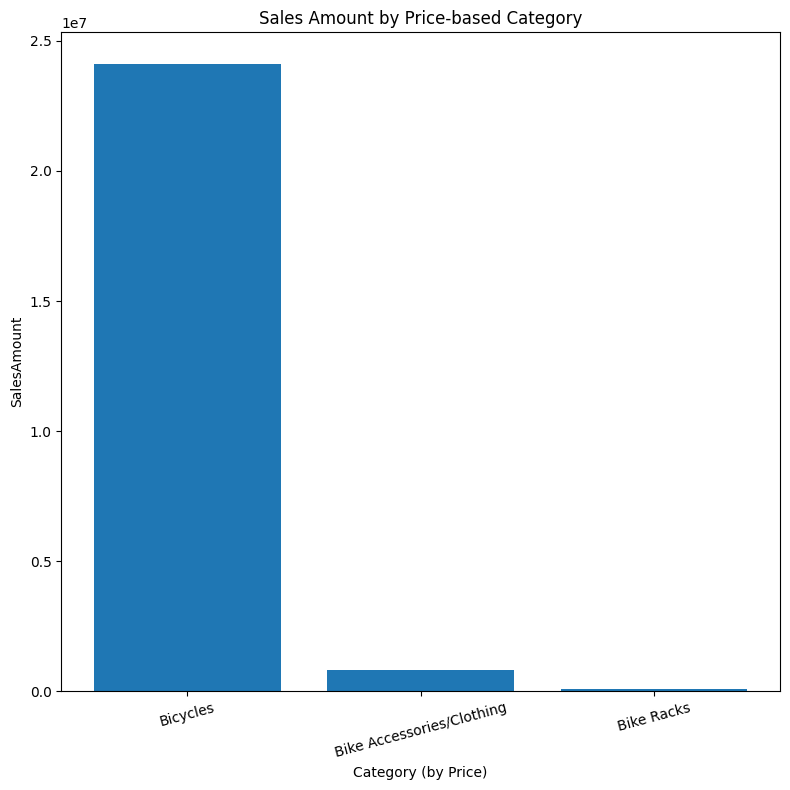

In [49]:
plt.figure(figsize=(8,8))
plt.bar(category_sales["Category_ByPrice"].astype(str), category_sales[sales_col].values)
plt.title("Sales Amount by Price-based Category")
plt.xlabel("Category (by Price)")
plt.ylabel(sales_col)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

I category the products by their price, I find that the bikes are most sold.
